In [56]:
# %pip install nbformat
# !pip install nltk
# !pip install -U kaleido

In [57]:
# Import dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import os

In [58]:
# Display settings for better readability
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 10)  # Display only the first 10 rows in output

In [59]:
# Reading all xlsx files
Competitor_reviews_df = pd.read_excel('CLEANEDCompetitor2024-07-31-13-20-43-Reviews_Export_Compall.xlsx')
Competitor_highest_sales_loss_df = pd.read_excel('CompetitorHighestSalesLossOSS_vs_Surewerx_ProductsJune1July30.xlsx')
Competitor_popular_keywords_df = pd.read_excel('CompetitorMostPopularKeywordswithASFRJune1July31.xlsx')
Competitor_OOS_highest_sales_loss_df = pd.read_excel('CompetitorProductsWithHighestSalesLossDueToOOSJune1July30.xlsx')
Competitor_Negative_sales_change_5000 = pd.read_excel('CompetitorSalesNegativeChangedProductsAbove5000.xlsx')

In [60]:
# Displaying the first few rows of each dataframe to understand their structure
# print(Competitor_reviews_df.head())
# print(Surewerx_reviews_df.head())
# print(Competitor_highest_sales_loss_df.head())
# print(Competitor_popular_keywords_df.head())
# print(Competitor_OOS_highest_sales_loss_df.head())
# print(Competitor_Negative_sales_change_5000.head())

In [ ]:
# Clean Competitor_reviews_df
# Only drop rows where 'Product Title', 'Cumulative Star Rating', or 'Cumulative Reviews' are missing
Competitor_reviews_df.dropna(subset=['Product Title', 'Cumulative Star Rating', 'Cumulative Reviews'], inplace=True)
Competitor_reviews_df['Cumulative Star Rating'] = Competitor_reviews_df['Cumulative Star Rating'].astype(float)
Competitor_reviews_df['Cumulative Reviews'] = Competitor_reviews_df['Cumulative Reviews'].astype(int)

# Remove duplicates based on 'Product Title', 'Cumulative Star Rating', and 'Cumulative Reviews'
Competitor_reviews_df = Competitor_reviews_df.drop_duplicates(subset=['Product Title', 'Cumulative Star Rating', 'Cumulative Reviews'])

# Display data info to check data types and missing values
print(Competitor_reviews_df.info())

# Display the first few cleaned rows to verify
print(Competitor_reviews_df.head())


In [62]:
# Basic descriptive statistics
print(Competitor_reviews_df.describe())

       Cumulative Star Rating  Cumulative Reviews  Star Rating
count              157.000000          157.000000   157.000000
mean                 4.398726          176.203822     2.566879
std                  0.232596          226.589110     1.688095
min                  3.500000            2.000000     1.000000
25%                  4.300000           30.000000     1.000000
50%                  4.500000           91.000000     2.000000
75%                  4.500000          231.000000     4.000000
max                  4.800000         1255.000000     5.000000


In [63]:
# Group by Account Category and aggregate data
category_analysis = Competitor_reviews_df.groupby('Account Category').agg({
    'Product Model Number': 'count',
    'Cumulative Star Rating': 'mean',
    'Cumulative Reviews': 'sum'
}).reset_index()

# Rename columns for clarity
category_analysis.columns = ['Category', 'Product Count', 'Average Star Rating', 'Total Reviews']

# Display the category analysis
print(category_analysis)

         Category  Product Count  Average Star Rating  Total Reviews
0  Above the Neck            117             4.395082          20172
1  Safety Apparel             32             4.425000           7444
2   Uncategorized              2             4.266667             48


In [ ]:
# Identify top products based on reviews and ratings
top_products = Competitor_reviews_df.sort_values(by=['Cumulative Reviews', 'Cumulative Star Rating'], ascending=False).head(10)

# Display the top products
print(top_products)

In [ ]:
# Identify top 50 products based on cumulative star ratings and reviews
top_products = Competitor_reviews_df.sort_values(by=['Cumulative Star Rating', 'Cumulative Reviews'], ascending=False).head(50)

# Display the top products
print(top_products)

In [ ]:
# Combine Product Title and Product Model Number
top_products['Product Title (Model Number)'] = top_products['Product Title'] + ' (' + top_products['Product Model Number'] + ')'

# Visualization: Top 50 performing products in a horizontal bar chart
plt.figure(figsize=(12, 16))
sns.barplot(
    x='Cumulative Star Rating', 
    y='Product Title (Model Number)', 
    data=top_products, 
    palette='viridis'
)
plt.xlabel('Cumulative Star Rating')
plt.ylabel('Product Title (Model Number)')
plt.title('Top 50 Performing Products by Cumulative Star Rating (Mean of Ratings: 4.39)')

plt.show()

# #save 50 products to xlsx
# top_products.to_excel('top50products.xlsx', index=False)

In [67]:
# Data preparation
reviews_by_category = category_analysis.groupby('Category')['Total Reviews'].sum().reset_index()

# Visualization: Pie chart for total reviews by category
fig = px.pie(reviews_by_category, values='Total Reviews', names='Category', 
             title='Total Reviews by Category', color_discrete_sequence=px.colors.sequential.Viridis)

# Update the traces to include both percentage and total review count
fig.update_traces(textinfo='percent+label+value')

# Show the figure
fig.show()


In [68]:
# Running below code will provide a list of products with low star ratings and high review counts, along with their review summaries. 
# This information can be analyzed to understand common issues and weaknesses in Competitor products.

In [ ]:
# Identify the top 30 products based on cumulative reviews and then ratings
top_by_reviews = Competitor_reviews_df.sort_values(by=['Cumulative Reviews', 'Cumulative Star Rating'], ascending=False).head(30)
top_by_ratings = Competitor_reviews_df.sort_values(by=['Cumulative Star Rating', 'Cumulative Reviews'], ascending=False).head(30)

# Combine Product Title and Product Model Number for top_by_reviews
top_by_reviews['Product Title (Model Number)'] = top_by_reviews['Product Title'] + ' (' + top_by_reviews['Product Model Number'] + ')'

# Combine Product Title and Product Model Number for top_by_ratings
top_by_ratings['Product Title (Model Number)'] = top_by_ratings['Product Title'] + ' (' + top_by_ratings['Product Model Number'] + ')'

# Visualization for top products by reviews
plt.figure(figsize=(12, 10))  # Adjusted figure size for a more compact view
sns.barplot(
    x='Cumulative Reviews', 
    y='Product Title (Model Number)', 
    data=top_by_reviews, 
    palette='viridis'
)
plt.xlabel('Cumulative Reviews')
plt.ylabel('Product Title (Model Number)')
plt.title('Top 30 Products by Cumulative Reviews')
plt.show()


# Visualization for top products by ratings
plt.figure(figsize=(12, 10))  # Adjusted figure size for a more compact view
sns.barplot(
    x='Cumulative Star Rating', 
    y='Product Title (Model Number)', 
    data=top_by_ratings, 
    palette='viridis'
)
plt.xlabel('Cumulative Star Rating')
plt.ylabel('Product Title (Model Number)')
plt.title('Top 30 Products by Cumulative Star Rating')

plt.show()

In [ ]:
# Extracting the top 30 product model numbers and titles based on reviews
top30_reviews_products = top_by_reviews[['Product Model Number', 'Product Title']]

# Extracting the top 30 product model numbers and titles based on ratings
top30_ratings_products = top_by_ratings[['Product Model Number', 'Product Title']]

# Combine both dataframes to have a single view
top30_combined = pd.concat([top30_reviews_products, top30_ratings_products]).drop_duplicates().reset_index(drop=True)

# # Save to Excel file
# top30_combined.to_excel('Top30_Products_by_Reviews_and_Ratings.xlsx', index=False)

# Display the combined dataframe to verify
print(top30_combined)


In [ ]:
# Define thresholds for weakness analysis
low_star_rating_threshold = 4.0
high_review_count_threshold = 15

# Filter products with low star ratings and high review counts
weaknesses_df = Competitor_reviews_df[
    (Competitor_reviews_df['Cumulative Star Rating'] < low_star_rating_threshold) & 
    (Competitor_reviews_df['Cumulative Reviews'] > high_review_count_threshold)
]

# Display the product titles and their associated review summaries to identify common issues
weaknesses_analysis = weaknesses_df[['Product Title', 'Product Model Number', 'Cumulative Star Rating', 'Cumulative Reviews', 'Review Summary']]

# Aggregating common issues from review summaries
common_issues = weaknesses_analysis.groupby(['Product Title', 'Product Model Number'])['Review Summary'].apply(lambda x: ' | '.join(x)).reset_index()
common_issues = common_issues.rename(columns={'Review Summary': 'Common Issues'})

# Merge common issues back to the weaknesses analysis
weaknesses_analysis = weaknesses_analysis.drop_duplicates(subset=['Product Title', 'Product Model Number']).merge(common_issues, on=['Product Title', 'Product Model Number'])

# Combine product title and model number for pie chart labels
weaknesses_analysis['Product Info'] = weaknesses_analysis['Product Title'] + ' (' + weaknesses_analysis['Product Model Number'] + ')'

# Create a pie chart with Plotly
fig_pie = px.pie(
    weaknesses_analysis,
    values='Cumulative Reviews',
    names='Product Info',
    title='Competitor Weakness Analysis-Products with Star Ratings < 4 and Review Counts > 15'
)

# Update the layout for better aesthetics
fig_pie.update_layout(
    title_font_size=20,
    title_x=0.5
)

# Show the pie chart
fig_pie.show()

# Print the DataFrame to verify
print(weaknesses_analysis[['Product Info', 'Cumulative Reviews', 'Common Issues']])

# #save weaknesses to xlsx
# weaknesses_analysis.to_excel('weaknesses.xlsx', index=False)

In [ ]:
# Define thresholds for strength analysis
high_star_rating_threshold = 4.0
high_review_count_threshold = 750

# Filter products with high star ratings and high review counts
strengths_df = Competitor_reviews_df[
    (Competitor_reviews_df['Cumulative Star Rating'] >= high_star_rating_threshold) & 
    (Competitor_reviews_df['Cumulative Reviews'] > high_review_count_threshold)
]

# Display the product titles and their associated review summaries to identify common strengths
strengths_analysis = strengths_df[['Product Title', 'Product Model Number', 'Cumulative Star Rating', 'Cumulative Reviews', 'Review Summary']]

# Aggregating common strengths from review summaries
common_strengths = strengths_analysis.groupby(['Product Title', 'Product Model Number'])['Review Summary'].apply(lambda x: ' | '.join(x)).reset_index()
common_strengths = common_strengths.rename(columns={'Review Summary': 'Common Strengths'})

# Merge common strengths back to the strengths analysis
strengths_analysis = strengths_analysis.drop_duplicates(subset=['Product Title', 'Product Model Number']).merge(common_strengths, on=['Product Title', 'Product Model Number'])

# Combine product title and model number for pie chart labels
strengths_analysis['Product Info'] = strengths_analysis['Product Title'] + ' (' + strengths_analysis['Product Model Number'] + ')'

# Create a pie chart with Plotly
fig_pie = px.pie(
    strengths_analysis,
    values='Cumulative Reviews',
    names='Product Info',
    title='Competitor Strength Analysis-Products with Star Ratings > 4 and Review Counts > 750'
)

# Update the layout for better aesthetics
fig_pie.update_layout(
    title_font_size=20,
    title_x=0.5
)

# Show the pie chart
fig_pie.show()

# Print the DataFrame to verify
print(strengths_analysis[['Product Info', 'Cumulative Reviews', 'Common Strengths']])

# #save strengths to xlsx
# strengths_analysis.to_excel('strengths.xlsx', index=False)



In [ ]:
import nltk
from nltk.corpus import stopwords
import string
from collections import Counter


# Download stopwords
nltk.download('stopwords')

# Function to preprocess text
def preprocess_text(text):
    # Lowercase
    text = text.lower()
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Tokenize
    words = text.split()
    # Remove stopwords
    words = [word for word in words if word not in stopwords.words('english')]
    return words

# Define threshold for negative reviews (you should replace this with actual data loading step)
negative_review_threshold = 3.0

# Assuming Competitor_reviews_df is already loaded (please make sure to load your DataFrame here)
# For demonstration, let's assume it's loaded from a file like this:
Competitor_reviews_df = pd.read_excel('CLEANEDCompetitor2024-07-31-13-20-43-Reviews_Export_Compall.xlsx')

# Filter negative reviews
negative_reviews_df = Competitor_reviews_df[Competitor_reviews_df['Star Rating'] <= negative_review_threshold]

# Create a dictionary to store words and their associated products
word_product_dict = {}

# Process each review summary
for index, row in negative_reviews_df.iterrows():
    words = preprocess_text(row['Review Summary'])
    for word in words:
        if word not in word_product_dict:
            word_product_dict[word] = []
        word_product_dict[word].append((row['Product Title'], row['Product Model Number']))

# Calculate word frequencies
all_words = [word for sublist in [preprocess_text(summary) for summary in negative_reviews_df['Review Summary']] for word in sublist]
word_freq = Counter(all_words)
common_words = word_freq.most_common(20)

# Create a DataFrame for keywords and associated products
rows = []
for word, freq in common_words:
    products = word_product_dict.get(word, [])
    for title, model in set(products):
        rows.append({'Keyword': word, 'Product Title': title, 'Product Model Number': model})

keywords_df = pd.DataFrame(rows)

# # Save the DataFrame to an Excel file in the Output folder
# output_dir = 'Output'
# os.makedirs(output_dir, exist_ok=True)
# output_file_path = os.path.join(output_dir, 'Keywords_with_Products.xlsx')
# keywords_df.to_excel(output_file_path, index=False)

# # Display the file path to verify
# print(f"Excel file saved to: {output_file_path}")

# Display the content of the created file
print(keywords_df.head())


C:\Users\ykilinc\AppData\Local\Temp\ipykernel_20220\1988020523.py:54: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




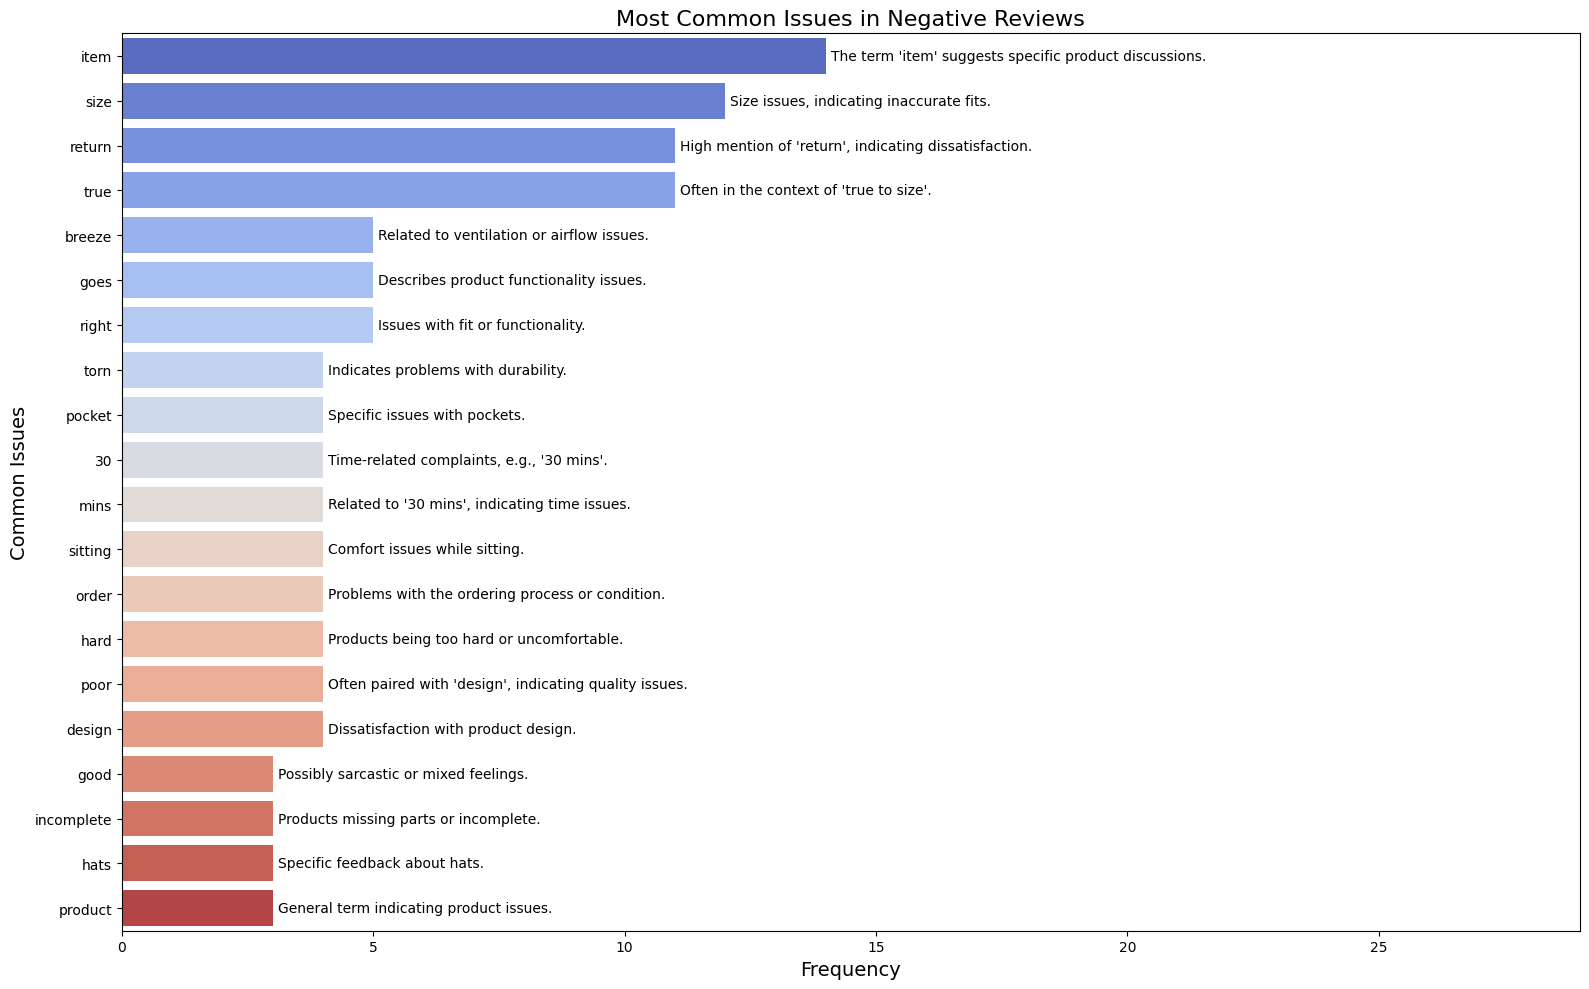

In [74]:
# Example word frequency data
common_words = [
    ('item', 14), 
    ('size', 12), 
    ('return', 11), 
    ('true', 11), 
    ('breeze', 5), 
    ('goes', 5), 
    ('right', 5), 
    ('torn', 4), 
    ('pocket', 4), 
    ('30', 4), 
    ('mins', 4), 
    ('sitting', 4), 
    ('order', 4), 
    ('hard', 4), 
    ('poor', 4), 
    ('design', 4), 
    ('good', 3), 
    ('incomplete', 3), 
    ('hats', 3), 
    ('product', 3)
]

# Adding descriptive annotations for common issues
descriptive_annotations = {
    'item': "The term 'item' suggests specific product discussions.",
    'size': "Size issues, indicating inaccurate fits.",
    'return': "High mention of 'return', indicating dissatisfaction.",
    'true': "Often in the context of 'true to size'.",
    'breeze': "Related to ventilation or airflow issues.",
    'goes': "Describes product functionality issues.",
    'right': "Issues with fit or functionality.",
    'torn': "Indicates problems with durability.",
    'pocket': "Specific issues with pockets.",
    '30': "Time-related complaints, e.g., '30 mins'.",
    'mins': "Related to '30 mins', indicating time issues.",
    'sitting': "Comfort issues while sitting.",
    'order': "Problems with the ordering process or condition.",
    'hard': "Products being too hard or uncomfortable.",
    'poor': "Often paired with 'design', indicating quality issues.",
    'design': "Dissatisfaction with product design.",
    'good': "Possibly sarcastic or mixed feelings.",
    'incomplete': "Products missing parts or incomplete.",
    'hats': "Specific feedback about hats.",
    'product': "General term indicating product issues."
}

# Convert common words to a DataFrame for plotting
common_words_df = pd.DataFrame(common_words, columns=['Word', 'Frequency'])

# Plotting
plt.figure(figsize=(16, 10))
ax = sns.barplot(x='Frequency', y='Word', data=common_words_df, palette='coolwarm')
plt.xlabel('Frequency', fontsize=14)
plt.ylabel('Common Issues', fontsize=14)
plt.title('Most Common Issues in Negative Reviews', fontsize=16)

# Add annotations with bounding boxes and adjust plot limits
for i, row in common_words_df.iterrows():
    word = row['Word']
    frequency = row['Frequency']
    annotation = descriptive_annotations.get(word, '')
    ax.text(frequency + 0.1, i, annotation, va='center', ha='left', fontsize=10, color='black', 
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=1))

# Adjust the x-axis limit to ensure annotations fit within the plot
ax.set_xlim(0, common_words_df['Frequency'].max() + 15)

# Adjust the layout to make sure everything fits well
plt.tight_layout()

# #save figure to Output folder
# plt.savefig('Output/MostCommonIssuesInNegativeReviews.png')

plt.show()



In [ ]:
# Convert the common words list to a set for easy lookup
common_words_set = set(word for word, _ in common_words)

# Function to preprocess text
def preprocess_text(text):
    # Lowercase
    text = text.lower()
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Tokenize
    words = text.split()
    # Remove stopwords
    words = [word for word in words if word not in stopwords.words('english')]
    return words

# Define threshold for negative reviews
negative_review_threshold = 3.0

# Assuming Competitor_reviews_df is already loaded (please make sure to load your DataFrame here)
# For demonstration, let's assume it's loaded from a file like this:
Competitor_reviews_df = pd.read_excel('CLEANEDCompetitor2024-07-31-13-20-43-Reviews_Export_Compall.xlsx')

# Filter negative reviews
negative_reviews_df = Competitor_reviews_df[Competitor_reviews_df['Star Rating'] <= negative_review_threshold]

# Create a dictionary to store words and their associated products
word_product_dict = {}

# Process each review summary
for index, row in negative_reviews_df.iterrows():
    words = preprocess_text(row['Review Summary'])
    for word in words:
        if word in common_words_set:
            if word not in word_product_dict:
                word_product_dict[word] = []
            word_product_dict[word].append((row['Product Title'], row['Product Model Number']))

# Create a DataFrame for keywords and associated products
rows = []
for word, freq in common_words:
    products = word_product_dict.get(word, [])
    for title, model in set(products):
        rows.append({'Keyword': word, 'Product Title': title, 'Product Model Number': model})

keywords_df = pd.DataFrame(rows)

# # Save the DataFrame to an Excel file in the Output folder
# output_dir = 'Output'
# os.makedirs(output_dir, exist_ok=True)
# output_file_path = os.path.join(output_dir, 'Keywords_with_Products.xlsx')
# keywords_df.to_excel(output_file_path, index=False)

# # Display the file path to verify
# print(f"Excel file saved to: {output_file_path}")

# Display the content of the created file
print(keywords_df.head())


In [ ]:
# Check for duplicates
Competitor_Negative_sales_change_5000.drop_duplicates(inplace=True)

# Handle missing values for 'Average Price'
Competitor_Negative_sales_change_5000['Average Price'] = Competitor_Negative_sales_change_5000['Average Price'].replace('–', np.nan).astype(float)

# Display the first few rows to verify the changes
print(Competitor_Negative_sales_change_5000.head())


In [ ]:
# Replace NaNs in 'Product Model Number' with an empty string
Competitor_Negative_sales_change_5000['Product Model Number'].fillna('', inplace=True)

# Create a new column that combines Product Title and Product Model Number
Competitor_Negative_sales_change_5000['Product Info'] = Competitor_Negative_sales_change_5000['Product Title'] + ' (' + Competitor_Negative_sales_change_5000['Product Model Number'].astype(str) + ')'

# Sort data by 'Total $ Sales Change' from highest loss to lowest (ascending order)
sorted_data = Competitor_Negative_sales_change_5000.sort_values(by='Total $ Sales Change', ascending=True).reset_index(drop=True)

# Remove duplicate 'Product Info' entries if any (to avoid overlapping bars)
sorted_data = sorted_data.drop_duplicates(subset=['Product Info'])

# Visualization for Total $ Sales Change by Product
plt.figure(figsize=(8, 12))  # Adjusted figure size for better visibility
sns.barplot(
    x='Total $ Sales Change', 
    y='Product Info', 
    data=sorted_data, 
    palette='viridis'
)
plt.xlabel('Total $ Sales Change')
plt.ylabel('Product Title (Model Number)')
plt.title('Total $ Sales Change by Product')

# Invert the x-axis to make the bars extend from right to left
plt.gca().invert_xaxis()

plt.show()


In [ ]:
# Drop empty values in the 'Average Price' column
Competitor_Negative_sales_change_5000 = Competitor_Negative_sales_change_5000.dropna(subset=['Average Price'])

# Convert 'Average Price' to numeric (float) if it's not already
Competitor_Negative_sales_change_5000['Average Price'] = pd.to_numeric(Competitor_Negative_sales_change_5000['Average Price'], errors='coerce')

# Create a new column that combines Product Title and Product Model Number
Competitor_Negative_sales_change_5000['Product Info'] = Competitor_Negative_sales_change_5000['Product Title'] + ' (' + Competitor_Negative_sales_change_5000['Product Model Number'].astype(str) + ')'

# Calculate the average price for each unique 'Product Model Number'
average_price_data = Competitor_Negative_sales_change_5000.groupby('Product Model Number')['Average Price'].mean().reset_index()

# Merge the average price data back to get the product info
merged_data = average_price_data.merge(Competitor_Negative_sales_change_5000[['Product Model Number', 'Product Info']], on='Product Model Number').drop_duplicates('Product Model Number')

# Visualization for Product Model Number & Product Title with Average Price
plt.figure(figsize=(12, 10))  # Adjusted figure size for better visibility
sns.barplot(
    x='Average Price', 
    y='Product Info', 
    data=merged_data, 
    palette='viridis'
)
plt.xlabel('Average Price')
plt.ylabel('Product Title (Model Number)')
plt.title('Average Price by Product Model Number & Product Title')

plt.show()

#save to excel
merged_data.to_excel('CompetitorAveragePricebyProductModelNumberandTitle.xlsx', index=False)


In [79]:
# Calculate the performance by account category
category_performance = Competitor_Negative_sales_change_5000.groupby('Account Category').agg({
    'Total $ Sales Change': 'sum',
    '1P Unit Sales Change': 'sum',
    'Average Price': 'mean'
}).reset_index()

# Print the performance data
print(category_performance)



  Account Category  Total $ Sales Change  1P Unit Sales Change  Average Price
0   Above the Neck            -665080.45                -22558      31.615219
1   Safety Apparel             -66659.31                 -1276      40.548595
2    Uncategorized             -64022.11                 -1134      67.973404


In [80]:
# Performance by Account Category
category_performance = Competitor_Negative_sales_change_5000.groupby('Account Category').agg({
    'Total $ Sales Change': 'sum',
    '1P Unit Sales Change': 'sum',
    'Average Price': 'mean'
}).reset_index()

print(category_performance)

# Use absolute values for the pie chart to visualize negative sales changes
category_performance['Total $ Sales Change (abs)'] = category_performance['Total $ Sales Change'].abs()

# Pie Chart Visualization for Total $ Sales Change by Account Category
fig = px.pie(
    category_performance, 
    values='Total $ Sales Change (abs)', 
    names='Account Category', 
    title='Total Negative $ Sales Change by Category (last 60 days)', 
    color_discrete_sequence=px.colors.sequential.Viridis
)

# Update the traces to include both percentage and total sales change
fig.update_traces(textinfo='percent+label+value')

# Show the figure
fig.show()


  Account Category  Total $ Sales Change  1P Unit Sales Change  Average Price
0   Above the Neck            -665080.45                -22558      31.615219
1   Safety Apparel             -66659.31                 -1276      40.548595
2    Uncategorized             -64022.11                 -1134      67.973404


In [ ]:
# Ensure '1P Sales Lost Due to OOS' column is of string type and then replace commas
Competitor_OOS_highest_sales_loss_df['1P Sales Lost Due to OOS'] = Competitor_OOS_highest_sales_loss_df['1P Sales Lost Due to OOS'].astype(str).str.replace(',', '')

# Convert '1P Sales Lost Due to OOS' to numeric
Competitor_OOS_highest_sales_loss_df['1P Sales Lost Due to OOS'] = pd.to_numeric(Competitor_OOS_highest_sales_loss_df['1P Sales Lost Due to OOS'], errors='coerce')

# Sort the data to get the top 15 products by '1P Sales Lost Due to OOS'
top_15_oos = Competitor_OOS_highest_sales_loss_df.sort_values(by='1P Sales Lost Due to OOS', ascending=False).head(20)

# Bar Chart Visualization for 1P Sales Lost Due to OOS by Product Model Number
plt.figure(figsize=(12, 10))  # Adjusted figure size for better visibility
sns.barplot(
    x='1P Sales Lost Due to OOS', 
    y='Product Title', 
    data=top_15_oos, 
    palette='viridis'
)
plt.xlabel('Sales Lost Due to OOS (items)')
plt.ylabel('Product Title')
plt.title('Top 20 Products by Sales Lost Due to OOS')

plt.show()


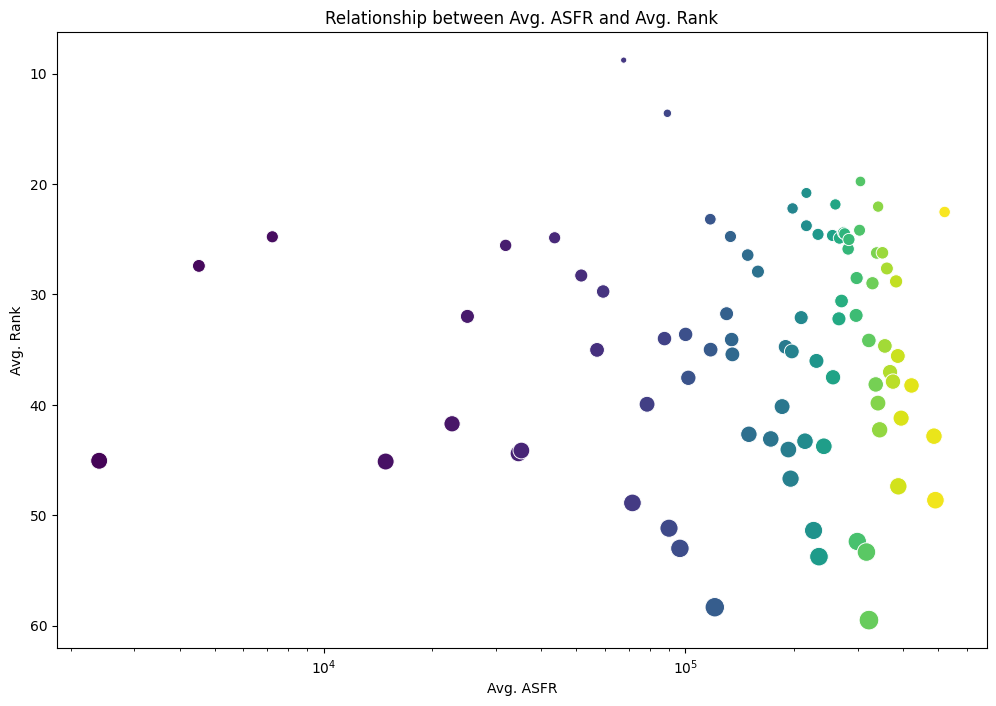

In [86]:
# Scatter plot to show the relationship between Avg. ASFR and Avg. Rank
plt.figure(figsize=(12, 8))
sns.scatterplot(data=Competitor_popular_keywords_df, x='Avg. ASFR', y='Avg. Rank', hue='Keyword', palette='viridis', size='Avg. Rank', sizes=(20, 200), legend=None)
plt.title('Relationship between Avg. ASFR and Avg. Rank')
plt.xlabel('Avg. ASFR')
plt.ylabel('Avg. Rank')
plt.xscale('log')
plt.gca().invert_yaxis()  # Higher rank is better
plt.show()


In [87]:
# Create a treemap for the keywords with Avg. ASFR
fig = px.treemap(
    Competitor_popular_keywords_df, 
    path=['Keyword'], 
    values='Avg. ASFR', 
    color='Avg. Rank',
    color_continuous_scale='Viridis',
    title='Treemap of Keywords by Avg. ASFR and Avg. Rank'
)

fig.update_layout(margin=dict(t=50, l=25, r=25, b=25))
fig.show()


In [88]:
# Define thresholds for high and low categories
asfr_threshold_high = Competitor_popular_keywords_df['Avg. ASFR'].median()
rank_threshold_high = Competitor_popular_keywords_df['Avg. Rank'].median()

# Filter data for High ASFR but Low Rank
high_asfr_low_rank = Competitor_popular_keywords_df[
    (Competitor_popular_keywords_df['Avg. ASFR'] > asfr_threshold_high) & 
    (Competitor_popular_keywords_df['Avg. Rank'] > rank_threshold_high)
]

# Filter data for Low ASFR but High Rank
low_asfr_high_rank = Competitor_popular_keywords_df[
    (Competitor_popular_keywords_df['Avg. ASFR'] < asfr_threshold_high) & 
    (Competitor_popular_keywords_df['Avg. Rank'] < rank_threshold_high)
]

# Treemap for High ASFR but Low Rank
fig_high_asfr_low_rank = px.treemap(
    high_asfr_low_rank, 
    path=['Keyword'], 
    values='Avg. ASFR', 
    color='Avg. Rank',
    color_continuous_scale='Viridis',
    title='High ASFR but Low Rank Keywords'
)

fig_high_asfr_low_rank.update_layout(margin=dict(t=50, l=25, r=25, b=25))
fig_high_asfr_low_rank.show()

# Treemap for Low ASFR but High Rank
fig_low_asfr_high_rank = px.treemap(
    low_asfr_high_rank, 
    path=['Keyword'], 
    values='Avg. ASFR', 
    color='Avg. Rank',
    color_continuous_scale='Viridis',
    title='Low ASFR but High Rank Keywords'
)

fig_low_asfr_high_rank.update_layout(margin=dict(t=50, l=25, r=25, b=25))
fig_low_asfr_high_rank.show()
